# 📄 Resume / Candidate Screening System
**Future Interns — Machine Learning Internship | Task 3**  
**CIN:** FIT/MAR26/ML6085  
**Repository:** FUTURE_ML_03

---
## Objective
Build an ML system that automatically screens resumes, matches candidates to a job description, ranks them by fit score, and highlights skill gaps — saving recruiters hours of manual review.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
PALETTE = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6','#EC4899','#06B6D4','#84CC16']

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Define Job Description
The role we are hiring for — a Machine Learning Engineer.

In [2]:
JOB_DESCRIPTION = """
We are looking for a Machine Learning Engineer to join our AI team.

Required Skills:
Python, machine learning, deep learning, TensorFlow, PyTorch, scikit-learn,
data analysis, pandas, numpy, SQL, statistics, model deployment, REST API,
computer vision, natural language processing, NLP, neural networks,
data preprocessing, feature engineering, model evaluation, Git, Docker

Responsibilities:
Build and deploy machine learning models for production use.
Perform data analysis and feature engineering on large datasets.
Collaborate with cross-functional teams to define AI solutions.
Evaluate model performance and optimize for accuracy and speed.
Write clean, maintainable Python code and document work on Git.

Qualifications:
Bachelor or Master degree in Computer Science, Data Science, or related field.
2+ years of experience with Python and machine learning frameworks.
Strong understanding of statistics and mathematical foundations of ML.
Experience with cloud platforms and model deployment pipelines.
"""

# Extract required skills list
REQUIRED_SKILLS = [
    'python', 'machine learning', 'deep learning', 'tensorflow', 'pytorch',
    'scikit-learn', 'data analysis', 'pandas', 'numpy', 'sql', 'statistics',
    'model deployment', 'rest api', 'computer vision', 'nlp', 'neural networks',
    'feature engineering', 'git', 'docker', 'data preprocessing'
]

print(f'📋 Job Role: Machine Learning Engineer')
print(f'🔑 Required Skills: {len(REQUIRED_SKILLS)}')
print(f'   {REQUIRED_SKILLS}')

📋 Job Role: Machine Learning Engineer
🔑 Required Skills: 20
   ['python', 'machine learning', 'deep learning', 'tensorflow', 'pytorch', 'scikit-learn', 'data analysis', 'pandas', 'numpy', 'sql', 'statistics', 'model deployment', 'rest api', 'computer vision', 'nlp', 'neural networks', 'feature engineering', 'git', 'docker', 'data preprocessing']


## 3. Create Candidate Resume Dataset
10 simulated candidates with varying levels of experience and skill match.

In [3]:
resumes = [
    {
        'name': 'Aisha Rahman',
        'experience_years': 5,
        'education': 'MSc Data Science',
        'resume_text': """
        Experienced ML Engineer with 5 years in Python, machine learning, deep learning,
        TensorFlow, PyTorch, scikit-learn. Strong in data analysis, pandas, numpy,
        SQL, statistics, model deployment, REST API development. Worked on computer vision
        and NLP projects. Expert in neural networks, feature engineering, Git, Docker.
        MSc Data Science. Deployed models in production using cloud platforms.
        Data preprocessing and model evaluation expert.
        """
    },
    {
        'name': 'James Carter',
        'experience_years': 3,
        'education': 'BSc Computer Science',
        'resume_text': """
        Data Scientist with 3 years experience. Proficient in Python, scikit-learn,
        pandas, numpy, data analysis, statistics, SQL, feature engineering.
        Built machine learning models for classification and regression.
        Experience with Git and basic model deployment. Familiar with neural networks.
        BSc Computer Science. Some exposure to NLP projects.
        """
    },
    {
        'name': 'Priya Nair',
        'experience_years': 4,
        'education': 'MTech AI',
        'resume_text': """
        AI Engineer specializing in deep learning and neural networks. Expert in
        TensorFlow, PyTorch, Python, computer vision, NLP, natural language processing.
        Strong background in data preprocessing, feature engineering, model evaluation.
        Used Docker, Git, REST API. Published research in computer vision.
        MTech Artificial Intelligence. Statistics and data analysis skills.
        """
    },
    {
        'name': 'David Okafor',
        'experience_years': 2,
        'education': 'BSc Mathematics',
        'resume_text': """
        Junior Data Analyst with 2 years experience. Strong in Python, pandas,
        numpy, SQL, statistics, data analysis. Built basic machine learning models
        using scikit-learn. Familiar with Git. Good mathematical background.
        BSc Mathematics. Currently learning deep learning and neural networks.
        No production deployment experience yet.
        """
    },
    {
        'name': 'Sofia Martinez',
        'experience_years': 6,
        'education': 'PhD Computer Science',
        'resume_text': """
        Senior ML Researcher with 6 years experience. Expert in Python, machine learning,
        deep learning, TensorFlow, PyTorch, neural networks, NLP, computer vision.
        Published 8 papers. Strong in statistics, data analysis, feature engineering,
        model evaluation, data preprocessing. Used Git, Docker. REST API development.
        SQL and model deployment experience. PhD Computer Science.
        scikit-learn, pandas, numpy expert.
        """
    },
    {
        'name': 'Liam Thompson',
        'experience_years': 1,
        'education': 'BSc Software Engineering',
        'resume_text': """
        Recent graduate with internship experience in Python and data analysis.
        Completed online courses in machine learning and scikit-learn.
        Basic pandas and numpy skills. Used Git for version control.
        BSc Software Engineering. Eager to learn deep learning and statistics.
        No SQL or deployment experience.
        """
    },
    {
        'name': 'Yuna Kim',
        'experience_years': 4,
        'education': 'MSc Computer Science',
        'resume_text': """
        ML Engineer with 4 years experience in Python, machine learning, scikit-learn,
        deep learning, TensorFlow. Strong data analysis, pandas, numpy, SQL, statistics.
        Model deployment using REST API and Docker. Feature engineering expert.
        Git user. NLP experience from previous role. Data preprocessing skills.
        MSc Computer Science. Model evaluation and optimization background.
        """
    },
    {
        'name': 'Carlos Mendez',
        'experience_years': 7,
        'education': 'MSc Data Engineering',
        'resume_text': """
        Senior Data Engineer with 7 years. Expert in SQL, Python, pandas, numpy,
        data analysis, data preprocessing, statistics, Git, Docker, REST API.
        Limited machine learning experience. No deep learning or neural network background.
        No TensorFlow or PyTorch. MSc Data Engineering. Strong in databases and pipelines.
        """
    },
    {
        'name': 'Fatima Al-Hassan',
        'experience_years': 3,
        'education': 'BSc Data Science',
        'resume_text': """
        Data Scientist with 3 years. Python, machine learning, scikit-learn,
        data analysis, pandas, numpy, SQL, statistics, feature engineering, Git.
        NLP projects using natural language processing techniques.
        Some model deployment experience. BSc Data Science. Basic Docker knowledge.
        Limited deep learning. No TensorFlow or PyTorch experience.
        """
    },
    {
        'name': 'Noah Williams',
        'experience_years': 2,
        'education': 'BSc Statistics',
        'resume_text': """
        Statistician transitioning into ML. Strong statistics, data analysis, Python,
        pandas, numpy, SQL. Recently started learning scikit-learn and machine learning.
        Used R and SPSS for statistical modeling. Git basics.
        BSc Statistics. No deep learning, deployment, or cloud experience.
        """
    }
]

df = pd.DataFrame(resumes)
print(f'✅ {len(df)} candidate resumes loaded')
df[['name','experience_years','education']]

✅ 10 candidate resumes loaded


,name,experience_years,education
0,Aisha Rahman,5,MSc Data Science
1,James Carter,3,BSc Computer Science
2,Priya Nair,4,MTech AI
3,David Okafor,2,BSc Mathematics
4,Sofia Martinez,6,PhD Computer Science
5,Liam Thompson,1,BSc Software Engineering
6,Yuna Kim,4,MSc Computer Science
7,Carlos Mendez,7,MSc Data Engineering
8,Fatima Al-Hassan,3,BSc Data Science
9,Noah Williams,2,BSc Statistics


## 4. Text Cleaning

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_resume'] = df['resume_text'].apply(clean_text)
clean_jd = clean_text(JOB_DESCRIPTION)

print('✅ Text cleaning complete')
print(f'\nSample cleaned resume (Aisha):')
print(df['clean_resume'].iloc[0][:300], '...')

✅ Text cleaning complete

Sample cleaned resume (Aisha):
experienced ml engineer with 5 years in python machine learning deep learning tensorflow pytorch scikit-learn strong in data analysis pandas numpy sql statistics model deployment rest api development worked on computer vision and nlp projects expert in neural networks feature engineering git docker  ...


## 5. Skill Extraction & Matching
Check which required skills each candidate has and doesn't have.

In [5]:
def extract_skills(resume_text, skill_list):
    found, missing = [], []
    text = resume_text.lower()
    for skill in skill_list:
        if skill.lower() in text:
            found.append(skill)
        else:
            missing.append(skill)
    return found, missing

df['skills_found']   = df['resume_text'].apply(lambda x: extract_skills(x, REQUIRED_SKILLS)[0])
df['skills_missing'] = df['resume_text'].apply(lambda x: extract_skills(x, REQUIRED_SKILLS)[1])
df['skill_count']    = df['skills_found'].apply(len)
df['skill_match_pct']= (df['skill_count'] / len(REQUIRED_SKILLS) * 100).round(1)

print('📊 Skill Match Summary:')
for _, row in df.iterrows():
    print(f"  {row['name']:20s} | {row['skill_count']:2d}/{len(REQUIRED_SKILLS)} skills | {row['skill_match_pct']}%")

📊 Skill Match Summary:
  Aisha Rahman         | 20/20 skills | 100.0%
  James Carter         | 13/20 skills | 65.0%
  Priya Nair           | 14/20 skills | 70.0%
  David Okafor         | 11/20 skills | 55.0%
  Sofia Martinez       | 20/20 skills | 100.0%
  Liam Thompson        | 10/20 skills | 50.0%
  Yuna Kim             | 17/20 skills | 85.0%
  Carlos Mendez        | 14/20 skills | 70.0%
  Fatima Al-Hassan     | 16/20 skills | 80.0%
  Noah Williams        | 10/20 skills | 50.0%


## 6. TF-IDF Cosine Similarity Scoring
Measure how similar each resume is to the job description.

In [6]:
all_docs = [clean_jd] + df['clean_resume'].tolist()

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(all_docs)

jd_vector       = tfidf_matrix[0]
resume_vectors  = tfidf_matrix[1:]
similarity_scores = cosine_similarity(jd_vector, resume_vectors)[0]

df['similarity_score'] = (similarity_scores * 100).round(1)

print('✅ Cosine similarity scores calculated')
print(f'\n📊 JD Similarity Scores:')
for _, row in df.iterrows():
    bar = '█' * int(row['similarity_score'] / 5)
    print(f"  {row['name']:20s} | {bar:20s} {row['similarity_score']}%")

✅ Cosine similarity scores calculated

📊 JD Similarity Scores:
  Aisha Rahman         | █████                26.2%
  James Carter         | ███                  17.2%
  Priya Nair           | ████                 20.0%
  David Okafor         | ██                   12.3%
  Sofia Martinez       | ████                 20.9%
  Liam Thompson        | ██                   10.7%
  Yuna Kim             | ███                  18.8%
  Carlos Mendez        | ██                   12.4%
  Fatima Al-Hassan     | ███                  18.0%
  Noah Williams        | ██                   10.6%


## 7. Composite Ranking Score
Combine skill match, JD similarity, and experience into one final score.

In [7]:
scaler = MinMaxScaler()

df['exp_scaled']        = scaler.fit_transform(df[['experience_years']]) * 100
df['similarity_scaled'] = df['similarity_score']
df['skill_scaled']      = df['skill_match_pct']

# Weighted composite score
# Skill match: 40% | JD Similarity: 40% | Experience: 20%
df['final_score'] = (
    df['skill_scaled']      * 0.40 +
    df['similarity_scaled'] * 0.40 +
    df['exp_scaled']        * 0.20
).round(1)

# Sort by final score
df = df.sort_values('final_score', ascending=False).reset_index(drop=True)
df['rank'] = range(1, len(df) + 1)

# Assign tier
def assign_tier(score):
    if score >= 75: return '🟢 Strong Match'
    elif score >= 55: return '🟡 Good Match'
    elif score >= 35: return '🟠 Partial Match'
    else: return '🔴 Weak Match'

df['tier'] = df['final_score'].apply(assign_tier)

print('🏆 CANDIDATE RANKING:')
print('=' * 70)
for _, row in df.iterrows():
    print(f"  #{row['rank']:2d} {row['name']:20s} | Score: {row['final_score']:5.1f} | {row['tier']}")
print('=' * 70)

🏆 CANDIDATE RANKING:
  # 1 Sofia Martinez       | Score:  65.0 | 🟡 Good Match
  # 2 Aisha Rahman         | Score:  63.8 | 🟡 Good Match
  # 3 Carlos Mendez        | Score:  53.0 | 🟠 Partial Match
  # 4 Yuna Kim             | Score:  51.5 | 🟠 Partial Match
  # 5 Priya Nair           | Score:  46.0 | 🟠 Partial Match
  # 6 Fatima Al-Hassan     | Score:  45.9 | 🟠 Partial Match
  # 7 James Carter         | Score:  39.5 | 🟠 Partial Match
  # 8 David Okafor         | Score:  30.3 | 🔴 Weak Match
  # 9 Noah Williams        | Score:  27.6 | 🔴 Weak Match
  #10 Liam Thompson        | Score:  24.3 | 🔴 Weak Match


## 8. Visualizations

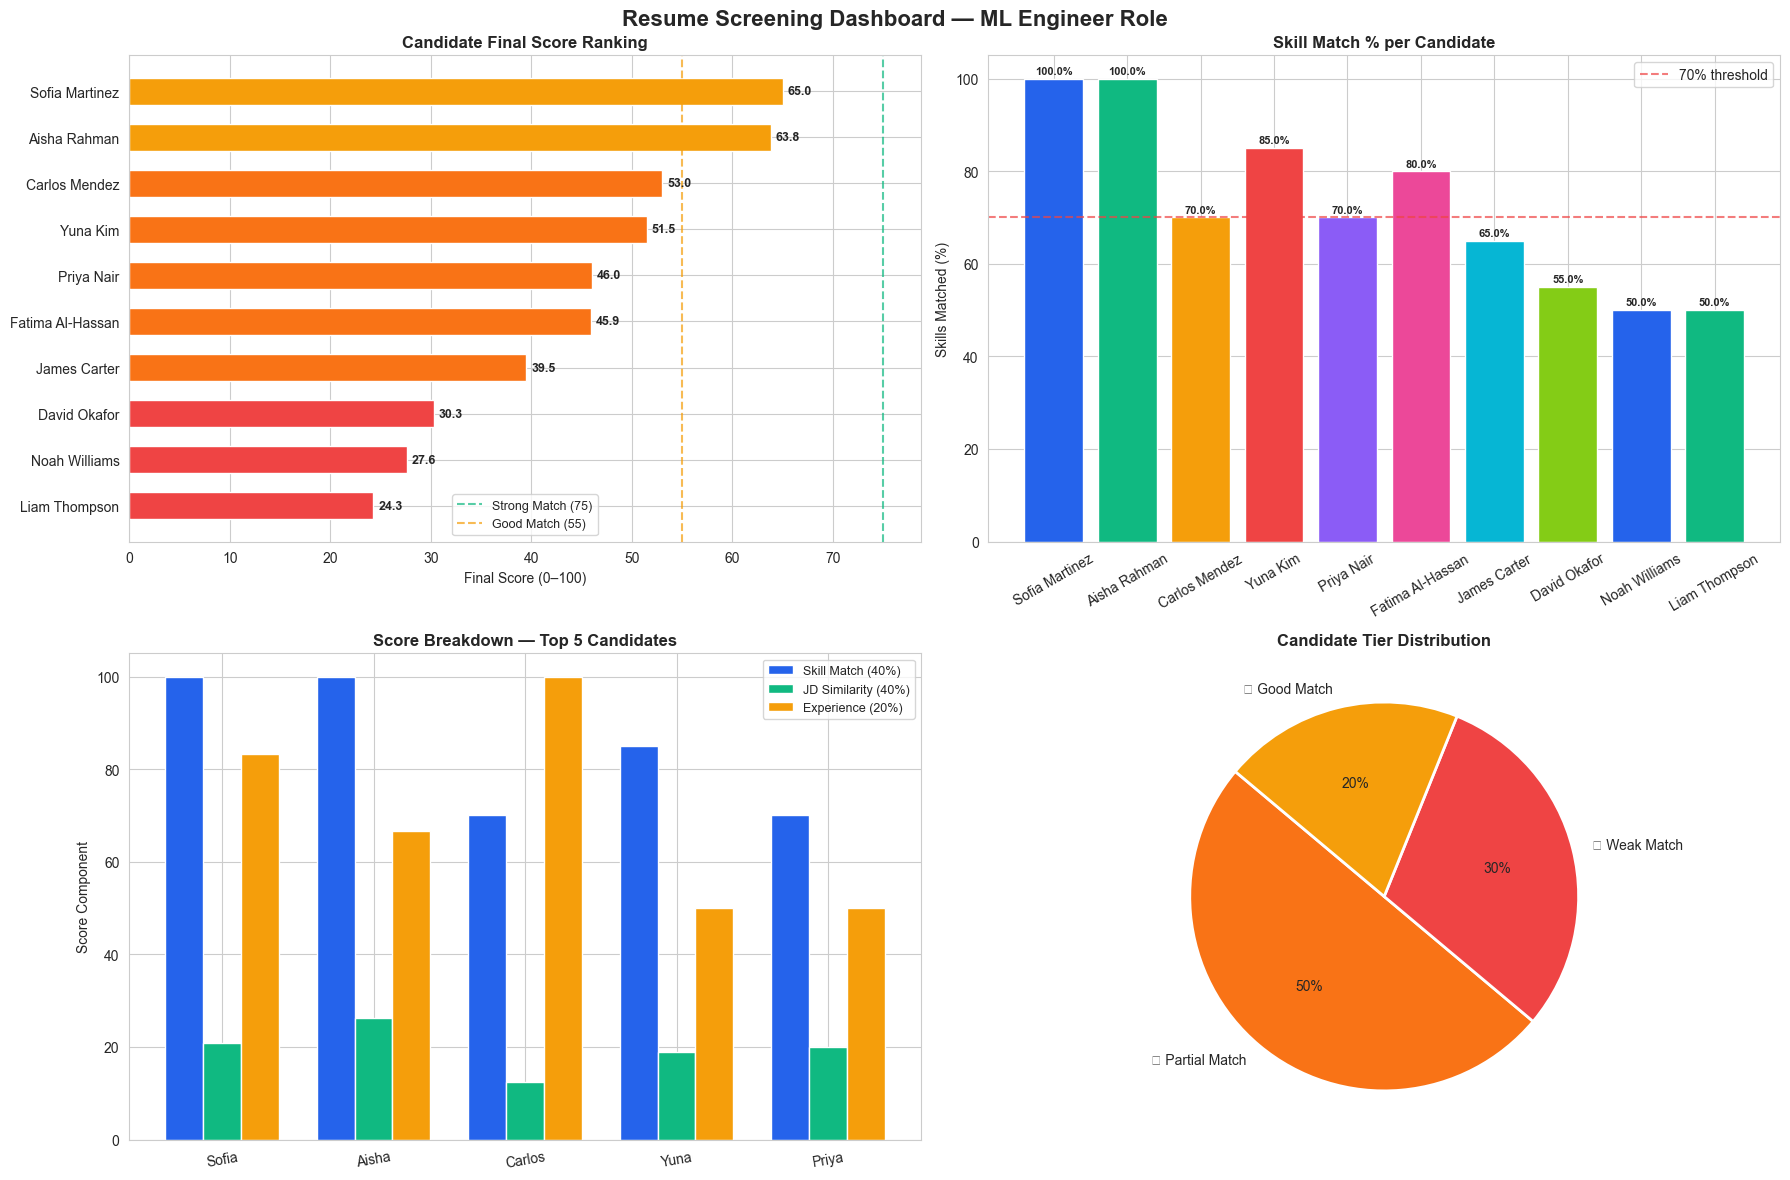

✅ Dashboard saved


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Resume Screening Dashboard — ML Engineer Role', fontsize=16, fontweight='bold')

tier_colors = {
    '🟢 Strong Match': '#10B981',
    '🟡 Good Match':   '#F59E0B',
    '🟠 Partial Match':'#F97316',
    '🔴 Weak Match':   '#EF4444'
}
bar_colors = [tier_colors[t] for t in df['tier']]

# 1. Final Score Ranking
bars = axes[0,0].barh(df['name'][::-1], df['final_score'][::-1],
                       color=bar_colors[::-1], edgecolor='white', height=0.6)
axes[0,0].set_title('Candidate Final Score Ranking', fontweight='bold')
axes[0,0].set_xlabel('Final Score (0–100)')
axes[0,0].axvline(75, color='#10B981', linestyle='--', alpha=0.7, label='Strong Match (75)')
axes[0,0].axvline(55, color='#F59E0B', linestyle='--', alpha=0.7, label='Good Match (55)')
axes[0,0].legend(fontsize=9)
for bar, score in zip(bars[::-1], df['final_score']):
    axes[0,0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                   f'{score}', va='center', fontsize=9, fontweight='bold')

# 2. Skill Match %
axes[0,1].bar(df['name'], df['skill_match_pct'], color=PALETTE[:len(df)], edgecolor='white')
axes[0,1].set_title('Skill Match % per Candidate', fontweight='bold')
axes[0,1].set_ylabel('Skills Matched (%)')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].axhline(70, color=PALETTE[3], linestyle='--', alpha=0.7, label='70% threshold')
axes[0,1].legend()
for i, (name, pct) in enumerate(zip(df['name'], df['skill_match_pct'])):
    axes[0,1].text(i, pct+1, f'{pct}%', ha='center', fontsize=8, fontweight='bold')

# 3. Score components breakdown (top 5)
top5 = df.head(5)
x = np.arange(len(top5))
w = 0.25
axes[1,0].bar(x-w, top5['skill_scaled'], w, label='Skill Match (40%)', color=PALETTE[0])
axes[1,0].bar(x,   top5['similarity_scaled'], w, label='JD Similarity (40%)', color=PALETTE[1])
axes[1,0].bar(x+w, top5['exp_scaled'], w, label='Experience (20%)', color=PALETTE[2])
axes[1,0].set_title('Score Breakdown — Top 5 Candidates', fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels([n.split()[0] for n in top5['name']], rotation=10)
axes[1,0].set_ylabel('Score Component')
axes[1,0].legend(fontsize=9)

# 4. Tier distribution pie
tier_counts = df['tier'].value_counts()
pie_colors = [tier_colors[t] for t in tier_counts.index]
axes[1,1].pie(tier_counts.values, labels=tier_counts.index,
              colors=pie_colors, autopct='%1.0f%%', startangle=140,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1,1].set_title('Candidate Tier Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('screening_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved')

## 9. Skill Gap Analysis

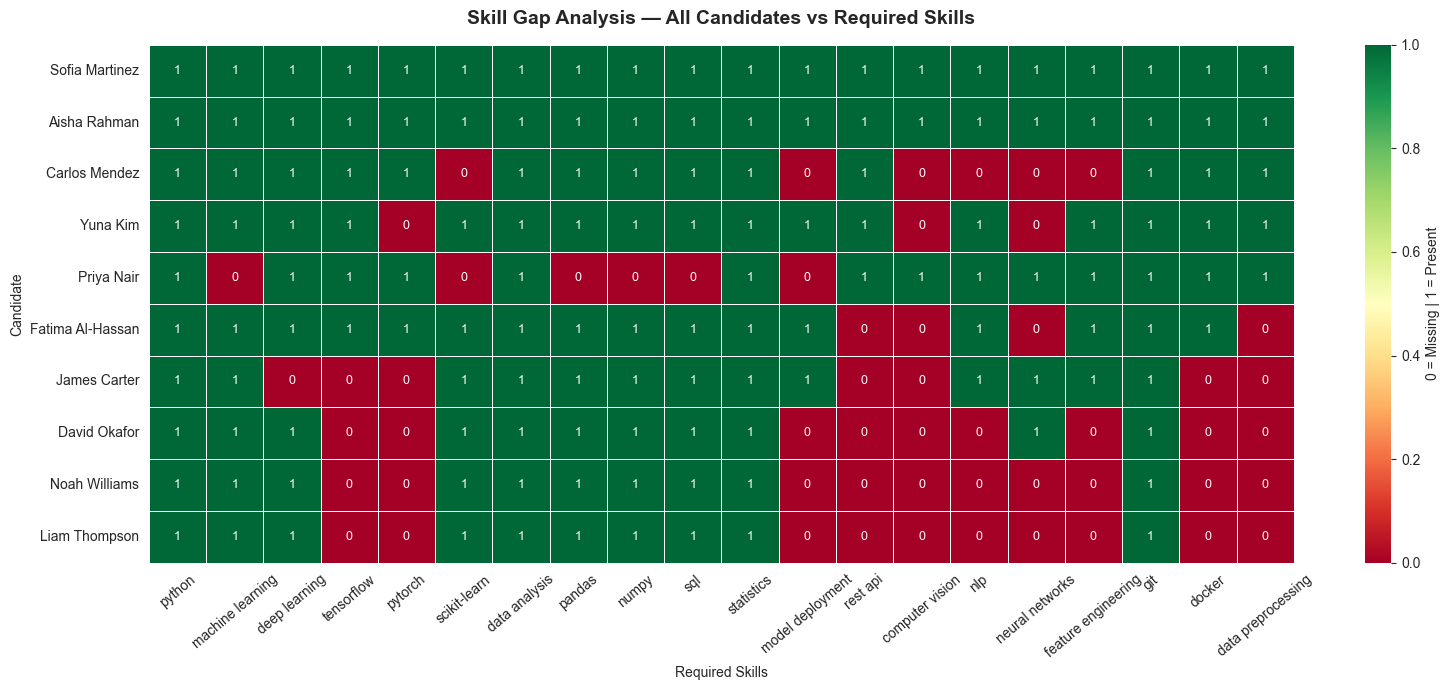

✅ Skill gap heatmap saved


In [9]:
fig, ax = plt.subplots(figsize=(16, 7))

skill_matrix = pd.DataFrame(
    [[1 if skill in row['skills_found'] else 0 for skill in REQUIRED_SKILLS]
     for _, row in df.iterrows()],
    index=df['name'],
    columns=REQUIRED_SKILLS
)

sns.heatmap(skill_matrix, cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': '0 = Missing | 1 = Present'},
            annot=True, fmt='d', annot_kws={'size': 9})
ax.set_title('Skill Gap Analysis — All Candidates vs Required Skills',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Required Skills')
ax.set_ylabel('Candidate')
ax.tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('skill_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Skill gap heatmap saved')

## 10. Detailed Candidate Report

In [10]:
print('=' * 65)
print('       📋 DETAILED CANDIDATE SCREENING REPORT')
print('       Role: Machine Learning Engineer')
print('=' * 65)

for _, row in df.iterrows():
    print(f"\n#{row['rank']} {row['name']} — {row['tier']}")
    print(f"   Education   : {row['education']}")
    print(f"   Experience  : {row['experience_years']} years")
    print(f"   Final Score : {row['final_score']}/100")
    print(f"   Skill Match : {row['skill_match_pct']}% ({row['skill_count']}/{len(REQUIRED_SKILLS)} skills)")
    print(f"   JD Similarity: {row['similarity_score']}%")
    if row['skills_missing']:
        print(f"   ⚠️  Missing   : {', '.join(row['skills_missing'][:5])}{'...' if len(row['skills_missing']) > 5 else ''}")
    else:
        print(f"   ✅ All required skills present!")

       📋 DETAILED CANDIDATE SCREENING REPORT
       Role: Machine Learning Engineer

#1 Sofia Martinez — 🟡 Good Match
   Education   : PhD Computer Science
   Experience  : 6 years
   Final Score : 65.0/100
   Skill Match : 100.0% (20/20 skills)
   JD Similarity: 20.9%
   ✅ All required skills present!

#2 Aisha Rahman — 🟡 Good Match
   Education   : MSc Data Science
   Experience  : 5 years
   Final Score : 63.8/100
   Skill Match : 100.0% (20/20 skills)
   JD Similarity: 26.2%
   ✅ All required skills present!

#3 Carlos Mendez — 🟠 Partial Match
   Education   : MSc Data Engineering
   Experience  : 7 years
   Final Score : 53.0/100
   Skill Match : 70.0% (14/20 skills)
   JD Similarity: 12.4%
   ⚠️  Missing   : scikit-learn, model deployment, computer vision, nlp, neural networks...

#4 Yuna Kim — 🟠 Partial Match
   Education   : MSc Computer Science
   Experience  : 4 years
   Final Score : 51.5/100
   Skill Match : 85.0% (17/20 skills)
   JD Similarity: 18.8%
   ⚠️  Missing   : py

## 11. Recruiter Recommendation

In [11]:
shortlist = df[df['final_score'] >= 55]
strong    = df[df['final_score'] >= 75]
reject    = df[df['final_score'] < 35]

print('=' * 55)
print('     🎯 RECRUITER RECOMMENDATIONS')
print('=' * 55)
print(f'\n✅ SHORTLIST ({len(shortlist)} candidates):')
for _, r in shortlist.iterrows():
    print(f'   #{r["rank"]} {r["name"]} — Score: {r["final_score"]}')

print(f'\n🏆 PRIORITY INTERVIEW ({len(strong)} candidates):')
for _, r in strong.iterrows():
    print(f'   #{r["rank"]} {r["name"]} — Score: {r["final_score"]}')

if len(reject) > 0:
    print(f'\n❌ DO NOT PROCEED ({len(reject)} candidates):')
    for _, r in reject.iterrows():
        print(f'   #{r["rank"]} {r["name"]} — Score: {r["final_score"]}')

print('\n' + '=' * 55)
print('💡 Business Recommendations:')
print(f'  1. Interview top {len(strong)} candidates immediately')
print(f'  2. Skill gap heatmap shows where training is needed')
print(f'  3. Adjust weights based on role priority (e.g. more exp weight for senior roles)')
print(f'  4. Retrain system with actual hiring decisions to improve over time')
print(f'  5. Use similarity threshold of 55+ for initial shortlisting')

     🎯 RECRUITER RECOMMENDATIONS

✅ SHORTLIST (2 candidates):
   #1 Sofia Martinez — Score: 65.0
   #2 Aisha Rahman — Score: 63.8

🏆 PRIORITY INTERVIEW (0 candidates):

❌ DO NOT PROCEED (3 candidates):
   #8 David Okafor — Score: 30.3
   #9 Noah Williams — Score: 27.6
   #10 Liam Thompson — Score: 24.3

💡 Business Recommendations:
  1. Interview top 0 candidates immediately
  2. Skill gap heatmap shows where training is needed
  3. Adjust weights based on role priority (e.g. more exp weight for senior roles)
  4. Retrain system with actual hiring decisions to improve over time
  5. Use similarity threshold of 55+ for initial shortlisting


---
## ✅ Task Complete

| Item | Status |
|---|---|
| Resume text cleaning & parsing | ✅ Done |
| Skill extraction & matching | ✅ Done |
| TF-IDF cosine similarity scoring | ✅ Done |
| Candidate ranking (composite score) | ✅ Done |
| Skill gap identification & heatmap | ✅ Done |
| Screening dashboard visualizations | ✅ Done |
| Recruiter recommendations | ✅ Done |

**GitHub Repository:** `FUTURE_ML_03`  
**Internship CIN:** FIT/MAR26/ML6085  
**Intern:** Fathima Safva